<a href="https://colab.research.google.com/github/kayeneii/Floodgate/blob/main/02_spatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 4: Spatial Analysis & Modeling

- Import the FRI raster and river shapefile.

- Create a river proximity surface.

- Identify high-risk flood corridors.

- Quantify and visualize flood-prone areas.

In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define base directory for project
base_dir = "/content/drive/MyDrive"

# Install necessary libraries
!pip install geopandas rasterio shapely matplotlib scipy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Paths to exported files
fri_path = f"{base_dir}/floodgate/fri_utm.tif"
rivers_path = f"{base_dir}/GEE_exports/hydro_rivers_bbox.shp"

### Import the FRI raster and river shapefile.

In [13]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Load FRI raster
fri_src = rasterio.open(fri_path)
fri = fri_src.read(1)
print("FRI Raster CRS:", fri_src.crs)
print("Raster shape:", fri.shape)

FRI Raster CRS: EPSG:32631
Raster shape: (3716, 3716)


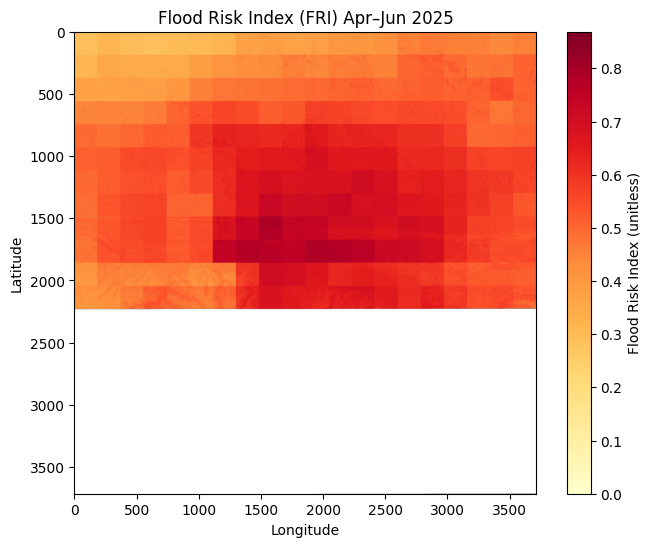

In [15]:
# Plot FRI data (handles NaN and nodata)
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show

# Read raster band and mask nodata
fri_data = fri_src.read(1, masked=True)

plt.figure(figsize=(8,6))
plt.imshow(fri_data, cmap='YlOrRd', vmin=np.nanmin(fri_data), vmax=np.nanmax(fri_data))
plt.colorbar(label="Flood Risk Index (unitless)")
plt.title("Flood Risk Index (FRI) Apr–Jun 2025")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In the map above, the detected bounding box geometry is outside (or misaligned with) the raster’s coordinate reference system. In plain terms, the cropping geometry (the bbox) doesn’t overlap with the raster grid. This is usually due to one of these three causes:

1. Lat/lon vs UTM mismatch (i.e., the raster is in meters (EPSG:32631), but the bbox was accidentally computed in degrees (lon/lat)).

2. Row/column → coordinate conversion issue (the xy() call produced wrong corner order).

3. NaN masking edge where all valid pixels are clustered at one side, but bounds were miscomputed.
<br>

**Fix:** Compute the valid-data bounding box directly in the raster’s own CRS (meters) using pixel coordinates → affine transform correctly.
- compute the bounding box of valid (non-NaN) pixels,
- crop the raster to that bbox,
- write a new repaired GeoTIFF, and
- plot it with north-up orientation.

In [44]:
!pip install rioxarray
import os
import rioxarray as rxr
import numpy as np
import rasterio
from rasterio import features
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box, mapping
import matplotlib.pyplot as plt
from rasterio.plot import show

In [28]:
# Input - change if your path differs
fri_input = f"{base_dir}/floodgate/fri_utm.tif"   # existing UTM FRI raster
out_dir = f"{base_dir}/floodgate"
os.makedirs(out_dir, exist_ok=True)
fri_repaired = os.path.join(out_dir, 'fri_utm_repaired.tif')

In [33]:
# Open and detect valid-data bbox
with rasterio.open(fri_input) as src:
    data = src.read(1, masked=True)
    transform = src.transform
    crs = src.crs
    meta = src.meta.copy()

    # Build valid mask (True = valid pixel)
    valid_mask = np.isfinite(data) & (~data.mask)

    # Verify valid pixels exist
    if not np.any(valid_mask):
        raise ValueError("❌ No valid pixels detected in the raster.")

    # Compute valid area bounds (in pixel coordinates)
    rows, cols = np.where(valid_mask)
    rmin, rmax = rows.min(), rows.max()
    cmin, cmax = cols.min(), cols.max()

    # Convert pixel coordinates to CRS coordinates (meters)
    from rasterio.transform import xy
    top_left = xy(transform, rmin, cmin, offset='ul')
    bottom_right = xy(transform, rmax, cmax, offset='lr')

    minx, maxy = top_left
    maxx, miny = bottom_right

    # Create bbox polygon (and add slight buffer for safety)
    bbox = box(minx, miny, maxx, maxy).buffer(1)  # 1 meter buffer

    print("✅ Detected valid-data bounding box:")
    print(f"   minx={minx:.2f}, miny={miny:.2f}, maxx={maxx:.2f}, maxy={maxy:.2f}")
    print(f"   CRS: {crs}")

✅ Detected valid-data bounding box:
   minx=499987.80, miny=663205.90, maxx=610706.37, maxy=773924.48
   CRS: EPSG:32631


In [35]:
# Safely mask/crop raster to valid area
from shapely.geometry import mapping
with rasterio.open(fri_input) as src:
    try:
        out_image, out_transform = mask(src, [mapping(bbox)], crop=True)
    except ValueError as e:
        print("⚠️ Initial crop failed, retrying with small buffer expansion...")
        bbox = bbox.buffer(50)  # expand 50 m
        out_image, out_transform = mask(src, [mapping(bbox)], crop=True)

    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

In [39]:
# Save repaired raster
with rasterio.open(fri_repaired, "w", **out_meta) as dst:
    dst.write(out_image)
print(f"🧭 Repaired raster saved to: {fri_repaired}")

🧭 Repaired raster saved to: /content/drive/MyDrive/floodgate/fri_utm_repaired.tif


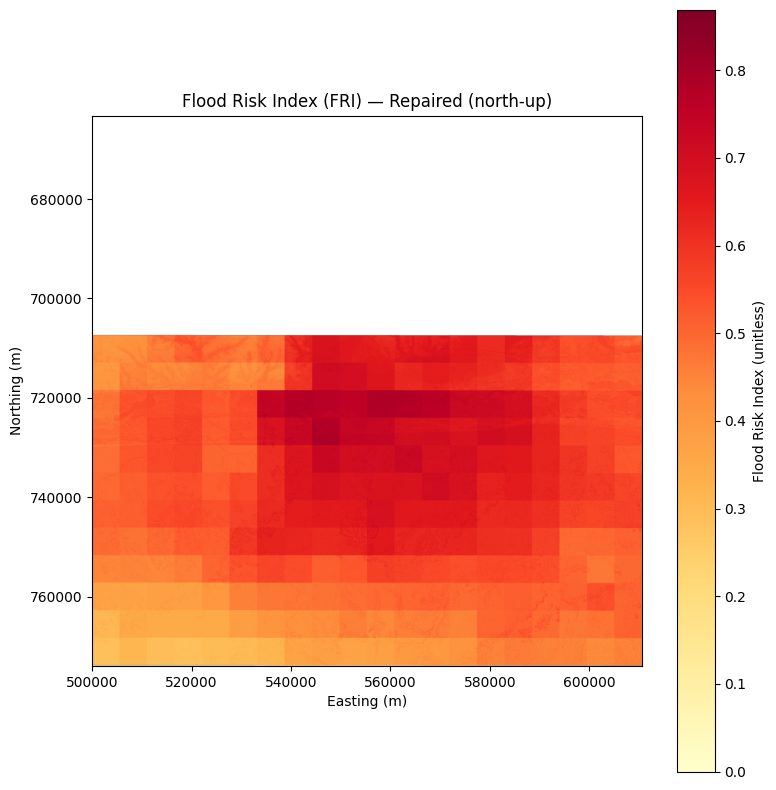

In [41]:
# Visualize result
import matplotlib.pyplot as plt
from rasterio.plot import show

with rasterio.open(fri_repaired) as src:
    fig, ax = plt.subplots(figsize=(8, 8))
    show(src.read(1, masked=True), transform=src.transform, cmap='YlOrRd', ax=ax)
    ax.set_ylim(ax.get_ylim()[::-1])  # North-up
    ax.set_title("Flood Risk Index (FRI) — Repaired (north-up)")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    img = ax.get_images()[0]
    plt.colorbar(img, ax=ax, label="Flood Risk Index (unitless)")
    plt.tight_layout()
    plt.show()

In [51]:
fri = f"{base_dir}/floodgate/fri_utm_repaired.tif"

with rasterio.open(fri) as src:
    data = src.read(1, masked=True)
    nodata = src.nodata
    min_val = np.nanmin(data)
    max_val = np.nanmax(data)

print("📊 FRI — Statistics & Metadata Summary")
print(f"  • CRS: {src.crs}")
print(f"  • Resolution: {src.res[0]:.2f} m")
print(f"  • Dimensions: {src.width} x {src.height}")
print(f"  • NoData Value: {nodata}")
print(f"  • Min Flood Risk: {min_val:.3f}")
print(f"  • Max Flood Risk: {max_val:.3f}")
print(f"  • Width (pixels): {src.width}")
print(f"  • Height (pixels): {src.height}")
print(f"  • Bounds (m): {src.bounds}\n")

# Compute extent in kilometers
width_m = src.bounds.right - src.bounds.left
height_m = src.bounds.top - src.bounds.bottom
print("📏 Map Extent (kilometers):")
print(f"  Width:  {width_m / 1000:.2f} km")
print(f"  Height: {height_m / 1000:.2f} km")

# Quick CRS sanity check
if 'UTM' in src.crs.to_string() or src.crs.is_projected:
  print("\n✅ Projection confirmed — raster is in a UTM (meter-based) CRS.")
else:
  print("\n⚠️  Warning: Raster still appears geographic (degrees). Reprojection may have failed.")


📊 FRI — Statistics & Metadata Summary
  • CRS: EPSG:32631
  • Resolution: 29.80 m
  • Dimensions: 3716 x 3716
  • NoData Value: None
  • Min Flood Risk: 0.000
  • Max Flood Risk: 0.869
  • Width (pixels): 3716
  • Height (pixels): 3716
  • Bounds (m): BoundingBox(left=499987.79547573614, bottom=663205.9025595716, right=610706.374672988, top=773924.4817568234)

📏 Map Extent (kilometers):
  Width:  110.72 km
  Height: 110.72 km

✅ Projection confirmed — raster is in a UTM (meter-based) CRS.


# River and FRI Overlap Check

In [57]:
import numpy as np
from shapely.geometry import box
from scipy.ndimage import distance_transform_edt

fri_fp = f"{base_dir}/floodgate/fri_utm_repaired.tif"   # existing UTM FRI raster
out_dir = f"{base_dir}/GEE_exports"
rivers_fp = f"{base_dir}/GEE_exports/hydro_rivers_bbox.shp"
os.makedirs(out_dir, exist_ok=True)

Original rivers CRS: EPSG:4326
Number of river features (original): 661


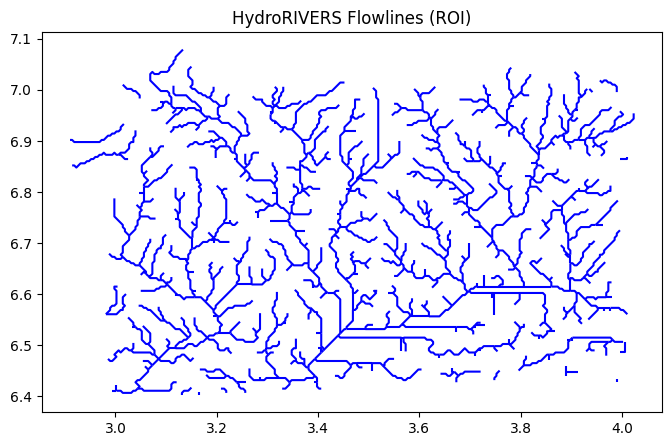

In [66]:
rivers = gpd.read_file(rivers_fp, encoding='ISO-8859-1')
print("Original rivers CRS:", rivers.crs)
print("Number of river features (original):", len(rivers))
rivers.plot(figsize=(8,6), color='blue')
plt.title("HydroRIVERS Flowlines (ROI)")
plt.show()

Rivers reprojected to: PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]


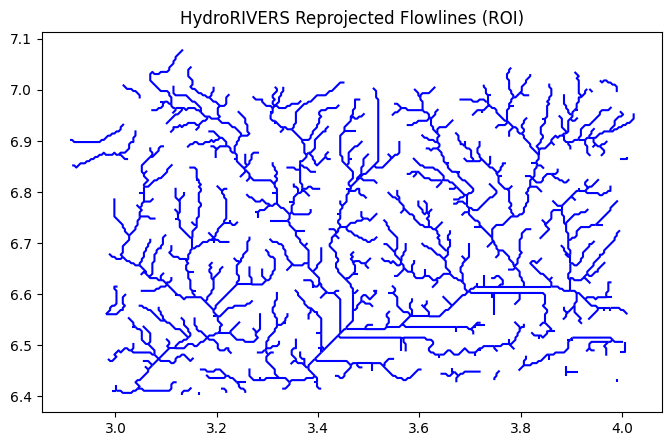

In [71]:
# 3) Reproject rivers to raster CRS (UTM) if needed
if rivers.crs is None:
    print("Warning: rivers shapefile has no CRS. Assuming EPSG:4326 (WGS84).")
    rivers = rivers.set_crs("EPSG:4326", allow_override=True)

if rivers.crs != fri_crs:
    rivers_utm = rivers.to_crs(fri_crs)
else:
    rivers_utm = rivers.copy()

print("Rivers reprojected to:", rivers_utm.crs)
rivers.plot(figsize=(8,6), color='blue')
plt.title("HydroRIVERS Reprojected Flowlines (ROI)")
plt.show()

In [68]:
# 4) Check overlap: compute intersection area ratio
fri_box = box(fri_bounds.left, fri_bounds.bottom, fri_bounds.right, fri_bounds.top)
rivers_within = rivers_utm[rivers_utm.intersects(fri_box)]

print("River features intersecting FRI extent:", len(rivers_within))

# Fraction of original features inside FRI bbox (rough sanity)
frac_in = len(rivers_within) / max(len(rivers), 1)
print(f"Fraction of river features inside raster bbox: {frac_in:.3f}")

River features intersecting FRI extent: 661
Fraction of river features inside raster bbox: 1.000


### River proximity and flood corridor masking

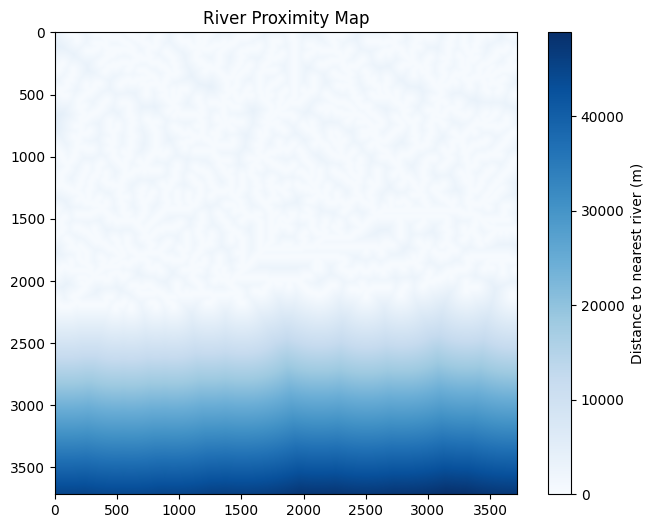

In [74]:
from rasterio import features
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt

# Ensure CRS consistency
assert rivers_utm.crs == fri_src.crs, "Reprojected rivers CRS does not match FRI CRS."


# Rasterize rivers - Use rivers_utm instead of rivers
rivers_raster = features.rasterize(
    [(geom, 1) for geom in rivers_utm.geometry if geom is not None],
    out_shape=fri_src.shape,
    transform=fri_src.transform,
    fill=0,
    dtype='uint8'
)

# Compute Euclidean distance (in pixels)
dist_pixels = distance_transform_edt(1 - rivers_raster)
pixel_size = abs(fri_src.transform.a)

# Convert pixels → meters (CRS-aware)
if fri_src.crs.is_geographic:
    lat_center = (fri_src.bounds.top + fri_src.bounds.bottom) / 2
    meters_per_deg = 111320 * np.cos(np.deg2rad(lat_center))
    dist_meters = dist_pixels * pixel_size * meters_per_deg
else:
    dist_meters = dist_pixels * pixel_size

# Define flood corridors
corridors = {
    "500m": dist_meters <= 500,
    "1000m": dist_meters <= 1000
}

# Visualize proximity
plt.figure(figsize=(8,6))
plt.imshow(dist_meters, cmap='Blues', origin='upper')
plt.colorbar(label='Distance to nearest river (m)')
plt.title("River Proximity Map")
plt.show()

In [78]:
# Save each corridor as GeoTIFF
for key, mask in corridors.items():
    out_fp = os.path.join(out_dir, f"flood_corridor_{key}.tif")
    mask_meta = fri_src.meta.copy()
    mask_meta.update({
        "dtype": "uint8",
        "count": 1
    })
    with rasterio.open(out_fp, "w", **mask_meta) as dst:
        dst.write(mask.astype("uint8"), 1)
    print(f"💾 Saved corridor mask: {out_fp}")

💾 Saved corridor mask: /content/drive/MyDrive/GEE_exports/flood_corridor_500m.tif
💾 Saved corridor mask: /content/drive/MyDrive/GEE_exports/flood_corridor_1000m.tif


### Identify high-risk flood corridors by combining with FRI

In [89]:
import numpy as np
import rasterio

fri_path = f"{base_dir}/floodgate/fri_utm_repaired.tif"

with rasterio.open(fri_path) as src:
    fri = src.read(1, masked=True)
    print(f"FRI dtype: {fri.dtype}")
    print(f"FRI shape: {fri.shape}")
    print(f"FRI has {np.sum(fri.mask)} masked pixels")
    print(f"Valid pixels: {np.sum(~fri.mask)}")
    print(f"Min: {fri.min()}, Max: {fri.max()}")
    print(f"Unique values (sample): {np.unique(fri.compressed())[:10]}")

FRI dtype: float32
FRI shape: (3716, 3716)
FRI has 0 masked pixels
Valid pixels: 1
Min: nan, Max: nan
Unique values (sample): [0.         0.28666666 0.287746   0.29421142 0.29784766 0.3016194
 0.30303463 0.30303466 0.3030347  0.30303472]


In [86]:
fri_data = fri.filled(np.nan)
valid_mask = ~np.isnan(fri_data)
print(f"Valid values: {np.sum(valid_mask)}")

if np.any(valid_mask):
    high_threshold = np.nanpercentile(fri_data, 75)
    print(f"🔥 High-risk FRI threshold: {high_threshold:.3f}")
else:
    print("⚠️ No valid FRI pixels found — check nodata definition.")

Valid values: 8283073
🔥 High-risk FRI threshold: 0.631


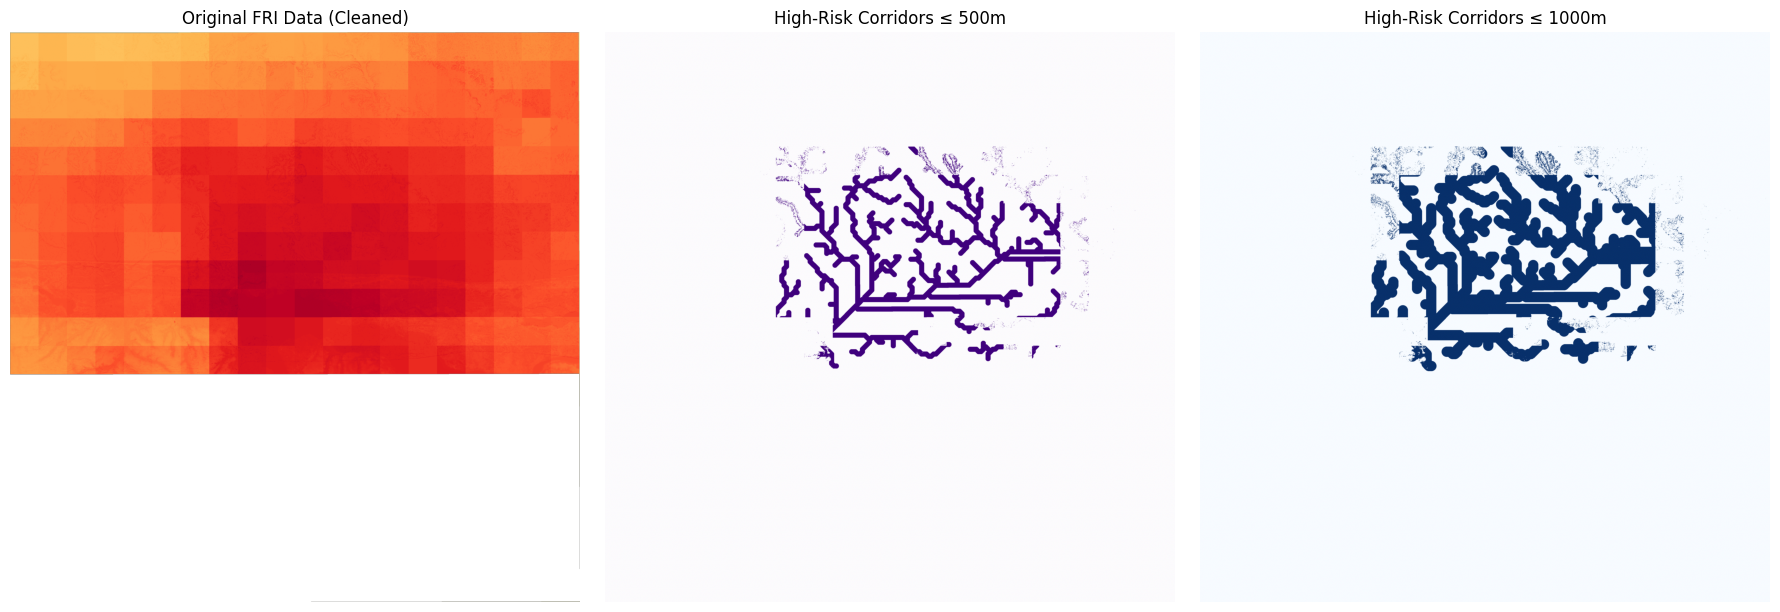

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio # Import rasterio

# 1️⃣ Load clean FRI data
fri_path = f"{base_dir}/floodgate/fri_utm_repaired.tif" # Ensure fri_path is defined
with rasterio.open(fri_path) as current_fri_src:
    fri_data_raw = current_fri_src.read(1, masked=True)
    fri_transform = current_fri_src.transform
    fri_crs = current_fri_src.crs
    fri_nodata = current_fri_src.nodata


# 2️⃣ Clean invalid / no-data cells
fri_data_clean = np.ma.filled(fri_data_raw, np.nan)

# Replace any explicit nodata value (if not already masked) with NaN
if fri_nodata is not None:
    fri_data_clean[fri_data_clean == fri_nodata] = np.nan

valid_mask = np.isfinite(fri_data_clean)

# 3️⃣ Identify high-risk areas
high_risk_threshold = 0.631
high_risk_mask = np.where(fri_data_clean >= high_risk_threshold, 1, 0)
high_risk_mask[np.isnan(fri_data_clean)] = 0 # Ensure NaN areas are not marked as high risk


# 4️⃣ Combine with corridors
high_corridor_500 = np.logical_and(corridors["500m"], high_risk_mask)
high_corridor_1000 = np.logical_and(corridors["1000m"], high_risk_mask)

# 5️⃣ Visualize everything clearly
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plotting the original FRI data as background for context (optional but good practice)
# Use the original extent from the source
from rasterio.plot import plotting_extent
extent = plotting_extent(current_fri_src)


axes[0].imshow(fri_data_clean, cmap='YlOrRd', origin='upper', extent=extent)
axes[0].set_title("Original FRI Data (Cleaned)")


axes[1].imshow(high_corridor_500, cmap="Purples", origin='upper', extent=extent)
axes[1].set_title("High-Risk Corridors ≤ 500m")

axes[2].imshow(high_corridor_1000, cmap="Blues", origin='upper', extent=extent)
axes[2].set_title("High-Risk Corridors ≤ 1000m")

for ax in axes:
    ax.axis("off") # Turn off axes for cleaner map visualization

plt.tight_layout()
plt.show()

### Export flood corridor masks for cartography and QA in QGIS